# Plot figures for 2 new papers about the DM-z relation

Plot FRB DM-z relation for two recently paper:

[Surajit](https://ui.adsabs.harvard.edu/abs/2024arXiv241001974K/abstract)

[Kritti](https://ui.adsabs.harvard.edu/abs/2024arXiv240916964S/abstract)

In [1]:
import sys
sys.path.append('../../Python_scripts')

## Import packages
from config import *
from support import *
from cosmo_support import *

/home/zhuge/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Data pre-processing and visualization

In [2]:
df=pd.read_excel("../../Data/FRB_all.xlsx")
df=df[['FRB','z','DM','DM_ext','From']]
df.head()

,FRB,z,DM,DM_ext,From
0,FRB 20180814A,0.06800,190.900,103.300,Fan
1,FRB 20181030A,0.00385,103.396,62.296,Fan
2,FRB 20220529A,0.18390,246.000,206.000,Fan
3,FRB 20220610A,1.01600,1458.150,1427.150,Fan
4,FRB 20220717A,0.36295,637.340,519.040,Fan


## Add Blinkverse

In [3]:
df_bk=pd.read_excel('../../Data/FRB_Blinkverse.xlsx')
df_bk.head()

,No.,FRB,Telescope,gl,gb,DM,z,DM_MW,Repeater?,Ref
0,,,,(deg),(deg),(cm$^-3$ pc),(redshift),(cm$^-3$ pc),(y/n),
1,1,FRB 20121102A,Arecibo,174.95,-0.223,570,0.1927,366.37,n,(1)arXiv:1701.01100
2,2,FRB 20171020A,ASKAP,29.3,-51.3,114.1,0.00867,77.196,n,(2)arXiv:2305.17960
3,3,FRB 20180301A,Parkes,204.412,-6.481,522,0.3304,208.734,y,(3)arXiv:2108.01282
4,NaN,FRB 20180814A,CHIME,136.46,16.58,190.86,0.0781,NaN,NaN,NaN


In [4]:
print(df_bk.columns)

Index(['No. ', 'FRB', ' Telescope ', 'gl', 'gb', 'DM', 'z', 'DM_MW ',
       ' Repeater? ', ' Ref '],
      dtype='object')


In [5]:
df_bk=df_bk[['FRB','gl','gb','DM','z','DM_MW ',' Ref ']]
df_bk.drop(0, inplace=True)
df_bk['FRB'] = df_bk['FRB'].str.strip()  # delete ' ' 
df_bk.reset_index(drop=True, inplace=True)
df_bk.head()

,FRB,gl,gb,DM,z,DM_MW,Ref
0,FRB 20121102A,174.95,-0.223,570,0.1927,366.37,(1)arXiv:1701.01100
1,FRB 20171020A,29.3,-51.3,114.1,0.00867,77.196,(2)arXiv:2305.17960
2,FRB 20180301A,204.412,-6.481,522,0.3304,208.734,(3)arXiv:2108.01282
3,FRB 20180814A,136.46,16.58,190.86,0.0781,NaN,NaN
4,FRB 20180916B,129.71,3.73,350.2,0.0337,291.964,(4)arXiv:2001.02222


In [6]:
df_uniq=pd.DataFrame(columns=df_bk.columns)
for i, frb in enumerate(df_bk['FRB']):
    if df['FRB'].str.contains(frb).any():
        pass
    else:
        df_uniq = pd.concat([df_uniq, df_bk.loc[i,:].to_frame().T],ignore_index=True,axis=0)
df_uniq

,FRB,gl,gb,DM,z,DM_MW,Ref
0,FRB 20200120E,142.19,41.22,87.82,0.0008,57.817,kirsten2022repeating200120


In [7]:
cosmo = Planck18
z = 0.0008

luminosity_distance = cosmo.luminosity_distance(z)
comoving_distance = cosmo.comoving_distance(z)
angular_diameter_distance = cosmo.angular_diameter_distance(z)

print(f"dL: {luminosity_distance.to('Mpc')}")
print(f"dc: {comoving_distance.to('Mpc')}")
print(f"dA: {angular_diameter_distance.to('Mpc')}")

dL: 3.5468668586166796 Mpc
dc: 3.544031633310032 Mpc
dA: 3.541198674370536 Mpc


In [8]:
from ne2001 import density
import astropy.units as u

ne = density.ElectronDensity()

gl = 142.19 # degree
gb = 41.22 # degree

distance =  100000*u.pc

dm = ne.DM(gl, gb, distance)

print(f"DM_MW = {dm:.2f}")

DM_MW = 40.08 pc / cm3


Reference do not calculate DM_MW, using our result

In [9]:
new_row = pd.DataFrame([[df_uniq.loc[0,'FRB'], 
                        df_uniq.loc[0,'z'],
                        df_uniq.loc[0,'DM'],
                        df_uniq.loc[0,'DM']-40.08,
                        df_uniq.loc[0,' Ref ']
                        ]],columns=df.columns)
new_row

,FRB,z,DM,DM_ext,From
0,FRB 20200120E,0.0008,87.82,47.74,kirsten2022repeating200120


In [10]:
df=pd.concat([df,new_row],ignore_index=True,axis=0)
print(df.iloc[-1,:])

FRB                      FRB 20200120E
z                               0.0008
DM                               87.82
DM_ext                           47.74
From       kirsten2022repeating200120 
Name: 97, dtype: object


# Add CHIME

In [11]:
print(df.shape)
df.head()

(98, 5)


,FRB,z,DM,DM_ext,From
0,FRB 20180814A,0.06800,190.900,103.300,Fan
1,FRB 20181030A,0.00385,103.396,62.296,Fan
2,FRB 20220529A,0.18390,246.000,206.000,Fan
3,FRB 20220610A,1.01600,1458.150,1427.150,Fan
4,FRB 20220717A,0.36295,637.340,519.040,Fan


In [12]:
df_CHIME=pd.read_excel('../../Data/CHIME250211217.xlsx')
df_CHIME['Name'] = df_CHIME['Name'].str.replace('FRB', 'FRB ')
print(df_CHIME.shape)
df_CHIME.head()

(22, 17)


,Name,RA_FRB,Dec_FRB,berr,aerr,Angle,DM,Flux,Fluence,P(O|x),L_3GHz,HostCandidate,Observation,Redshift,Date,mr,Exposure
0,FRB 20230203A,151.66159,35.69410,0.033,0.300,10.15,420.1,6.2,173.0,0.938,< 4×10^29,J100639.32+354149.74,Keck-2023B-3,0.1464,2023-12-14,17.92,900.0
1,FRB 20230222A,106.96036,11.22452,0.033,0.356,7.58,706.1,4.5,129.2,0.985,< 3×10^29,J070750.52+111322.36,Lick-2023B-1,0.1223,2023-09-17,17.53,1200.0
2,FRB 20230222B,238.73912,30.89870,0.033,0.192,9.89,187.8,91.3,37.5,0.981,< 2×10^29,J155457.11+305359.55,Lick-2023B-1,0.1100,2023-09-17,17.42,1200.0
3,FRB 20230311A,91.10966,55.94595,0.033,0.262,9.68,364.3,9.5,12.2,0.774,< 5×10^29,J060426.51+555641.63,Keck-2023B-3,0.1918,2023-12-14,19.38,2700.0
4,FRB 20230703A,184.62445,48.72993,0.033,0.336,9.73,291.3,9.4,8.4,0.973,< 2×10^29,J121829.47+484330.12,Keck-2023B-3,0.1184,2023-12-14,18.08,900.0


In [13]:
df_CHIME = df_CHIME.dropna(subset=['Redshift'])
print(df_CHIME.shape)

(19, 17)


In [14]:
coords = SkyCoord(ra=df_CHIME['RA_FRB'].values*u.deg, 
                     dec=df_CHIME['Dec_FRB'].values*u.deg, 
                     frame='icrs')
    
galactic = coords.galactic

df_CHIME['gl'] = galactic.l.deg
df_CHIME['gb'] = galactic.b.deg

In [15]:
df_CHIME[['RA_FRB', 'Dec_FRB', 'gl', 'gb']].head()

,RA_FRB,Dec_FRB,gl,gb
0,151.66159,35.69410,188.712537,54.087027
1,106.96036,11.22452,204.716378,8.695736
2,238.73912,30.89870,49.617582,49.978721
3,91.10966,55.94595,157.713377,16.039468
4,184.62445,48.72993,137.209786,67.475021


In [16]:
cosmo = Planck18

df_CHIME['dis(Mpc)']=cosmo.comoving_distance(df_CHIME['Redshift'])/u.Mpc
df_CHIME['dis(Mpc)'].head()

0    625.988627
1    526.109208
2    474.646701
3    810.697651
4    509.827369
Name: dis(Mpc), dtype: float64

In [17]:
threshold=0.1
df_CHIME.loc[df_CHIME['dis(Mpc)'] > threshold, 'dis(Mpc)'] = threshold
df_CHIME['dis(Mpc)'].head()

0    0.1
1    0.1
2    0.1
3    0.1
4    0.1
Name: dis(Mpc), dtype: float64

In [18]:
from ne2001 import density

ne = density.ElectronDensity()

def calculate_MW_DM_batch(df):
    ne = density.ElectronDensity()
    dm_values = []

    for idx in range(len(df)):
        try:
            dm = ne.DM(
                l=df['gl'].iloc[idx],
                b=df['gb'].iloc[idx],
                d=df['dis(Mpc)'].iloc[idx] * u.Mpc
            )
            dm_value = dm.value
        except Exception as e:
            print(f"error when calculate {df_CHIME.loc[idx,'Name']}: {e}")
            dm_value = np.nan
        
        dm_values.append(dm_value)
    
    return np.array(dm_values)

df_CHIME['DM_MW'] = calculate_MW_DM_batch(df_CHIME)
df_CHIME['DM_MW'].head()

0     35.289509
1    120.072901
2     27.622927
3     85.994833
4     26.700601
Name: DM_MW, dtype: float64

In [19]:
df_CHIME['DM_ext']=df_CHIME['DM']-df_CHIME['DM_MW']
df_CHIME=df_CHIME[['Name', 'Redshift', 'DM', 'DM_ext']]
df_CHIME['From']='CHIME2025'
df_CHIME.head()

,Name,Redshift,DM,DM_ext,From
0,FRB 20230203A,0.1464,420.1,384.810491,CHIME2025
1,FRB 20230222A,0.1223,706.1,586.027099,CHIME2025
2,FRB 20230222B,0.1100,187.8,160.177073,CHIME2025
3,FRB 20230311A,0.1918,364.3,278.305167,CHIME2025
4,FRB 20230703A,0.1184,291.3,264.599399,CHIME2025


In [20]:
df_CHIME.rename(columns={'Name':'FRB',
                         'Redshift':'z'
                         }, inplace=True)
df_CHIME.head()

,FRB,z,DM,DM_ext,From
0,FRB 20230203A,0.1464,420.1,384.810491,CHIME2025
1,FRB 20230222A,0.1223,706.1,586.027099,CHIME2025
2,FRB 20230222B,0.1100,187.8,160.177073,CHIME2025
3,FRB 20230311A,0.1918,364.3,278.305167,CHIME2025
4,FRB 20230703A,0.1184,291.3,264.599399,CHIME2025


In [21]:
new_rows = df_CHIME[~df_CHIME['FRB'].isin(df['FRB'])]

print(df.shape)
df = pd.concat([df, new_rows], ignore_index=True)
print(df.shape)

(98, 5)
(117, 5)


In [22]:
df.head()

,FRB,z,DM,DM_ext,From
0,FRB 20180814A,0.06800,190.900,103.300,Fan
1,FRB 20181030A,0.00385,103.396,62.296,Fan
2,FRB 20220529A,0.18390,246.000,206.000,Fan
3,FRB 20220610A,1.01600,1458.150,1427.150,Fan
4,FRB 20220717A,0.36295,637.340,519.040,Fan


## Now preprocess df

Text(0.5, 1.0, 'Linear Regression (99% Confidence Interval)')

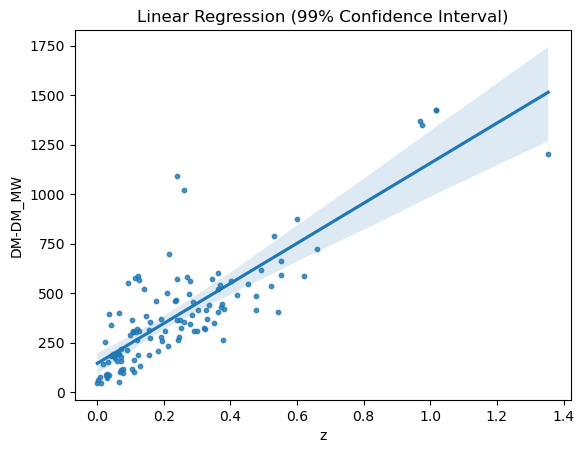

In [23]:
sns.regplot(data=df, x="z",y="DM_ext",ci=99,scatter_kws={"s":10})
plt.ylabel('DM-DM_MW')
plt.title('Linear Regression (99% Confidence Interval)')

In [24]:
# x=df['z']
# y=df['DM_ext']

# # linear fit
# slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# # prediction
# y_pred = slope * x + intercept

# def confidence_interval(x, y, y_pred, confidence=0.99):
#     n = len(x)
#     mean_x = np.mean(x)
    
#     # std
#     sum_sq = np.sum((y - y_pred) ** 2)
#     std_err = np.sqrt(sum_sq / (n-2))
    
#     x_new = np.column_stack([np.ones(len(x)), x])
#     mse = sum_sq / (n - 2)
#     var_b = mse * np.linalg.inv(np.dot(x_new.T, x_new))
    
#     std_fit = np.sqrt(np.diagonal(np.dot(x_new, np.dot(var_b, x_new.T))))
    
#     t = stats.t.ppf((1 + confidence) / 2, n - 2)
#     ci = t * std_fit
    
#     return ci

# # 95%
# ci = confidence_interval(x, y, y_pred)

# plt.figure(figsize=(10, 6))
# plt.scatter(x, y, color='blue', alpha=0.5, label='data points')
# plt.plot(x, y_pred, color='red', label='linear regression')
# plt.fill_between(x, y_pred - ci, y_pred + ci, color='gray', alpha=0.2, label='99% confidencial interval')

# plt.xlabel('X')
# plt.ylabel('Y')
# plt.title('linear regression and 99% confidencial interval')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

# print(f"slope: {slope:.4f}")
# print(f"intercept: {intercept:.4f}")
# print(f"R²: {r_value**2:.4f}")
# print(f"p value: {p_value:.4f}")

DM_MW, halo=30

In [25]:
DM_halo=30
df['DM_ext']=df['DM_ext']-DM_halo
df.head()

,FRB,z,DM,DM_ext,From
0,FRB 20180814A,0.06800,190.900,73.300,Fan
1,FRB 20181030A,0.00385,103.396,32.296,Fan
2,FRB 20220529A,0.18390,246.000,176.000,Fan
3,FRB 20220610A,1.01600,1458.150,1397.150,Fan
4,FRB 20220717A,0.36295,637.340,489.040,Fan


In [26]:
# df = df[df['FRB'] != 'FRB 20190520B']
# df = df[df['FRB'] != 'FRB 20220831A']
# 1012.637396992344

In [27]:
fit=np.polyfit(df['z'], df['DM_ext'],1)
slope, intercept = fit
print(slope, intercept)

1012.7299499564598 113.6993297793215


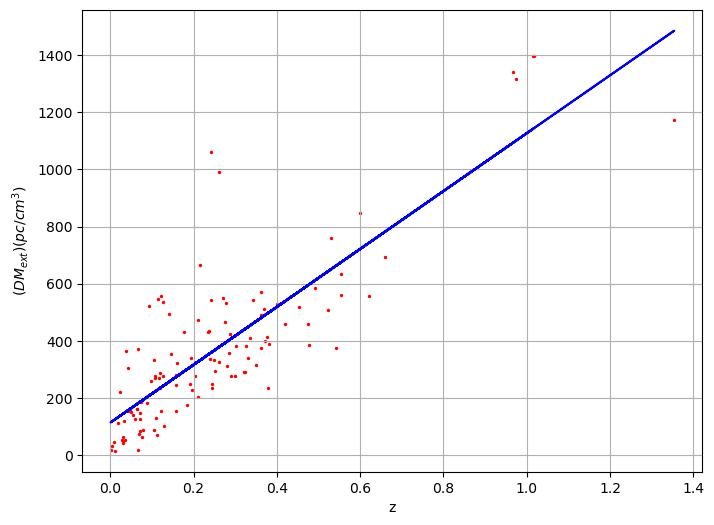

In [28]:
plt.figure(figsize=(8, 6))
plt.scatter(df['z'], df['DM_ext'],s=2,color='red')
plt.plot(df['z'],slope*df['z']+intercept,color='blue')
plt.xlabel('z')
plt.ylabel('$(DM_{ext})(pc/cm^3)$')
# plt.title('FRBs DM-z')
plt.grid(True)
plt.show()

Drop FRB 20190520B & FRB 20220831A

In [29]:
print(len(df))
#df = df[df['FRB'] != 'FRB 20190520B'] # no need to remove this FRB here.
#df = df[df['FRB'] != 'FRB 20220831A']
print(len(df))
df.head()

117
117


,FRB,z,DM,DM_ext,From
0,FRB 20180814A,0.06800,190.900,73.300,Fan
1,FRB 20181030A,0.00385,103.396,32.296,Fan
2,FRB 20220529A,0.18390,246.000,176.000,Fan
3,FRB 20220610A,1.01600,1458.150,1397.150,Fan
4,FRB 20220717A,0.36295,637.340,489.040,Fan


In [30]:
# Assuming your dataframe is named df
# 1. Find rows where DM_ext < 0
dropped_rows = df[df['DM_ext'] < 0]

# 2. Print FRB values of dropped rows if any exist
if not dropped_rows.empty:
    print("Dropped rows:")
    print(dropped_rows[['FRB', 'DM_ext']])
else:
    print("No rows with DM_ext < 0 found to drop")

# 3. Keep only rows where DM_ext >= 0
df = df[df['DM_ext'] >= 0]

print(f'Now there are {len(df)} rows in the dataframe')

No rows with DM_ext < 0 found to drop
Now there are 117 rows in the dataframe


In [31]:
df['DM_ext'] = df['DM_ext'].round(2)
df.to_csv("../../Data/FRB.csv",index=None)

# Macquart samples

In [32]:
Mac_frbs=['FRB 20180924B','FRB 20181112A','FRB 20190102C','FRB 20190608B','FRB 20190711A']

In [33]:
df_mac= df[df['FRB'].isin(Mac_frbs)]
df_mac

,FRB,z,DM,DM_ext,From
47,FRB 20180924B,0.3214,361.42,290.92,Surajit
48,FRB 20181112A,0.4755,589.27,457.27,Surajit
51,FRB 20190102C,0.2910,363.60,276.30,Surajit
58,FRB 20190608B,0.1178,338.70,271.50,Surajit
61,FRB 20190711A,0.5220,593.10,506.70,Surajit


Text(0.5, 1.0, 'Linear Regression (90% Confidence Interval)')

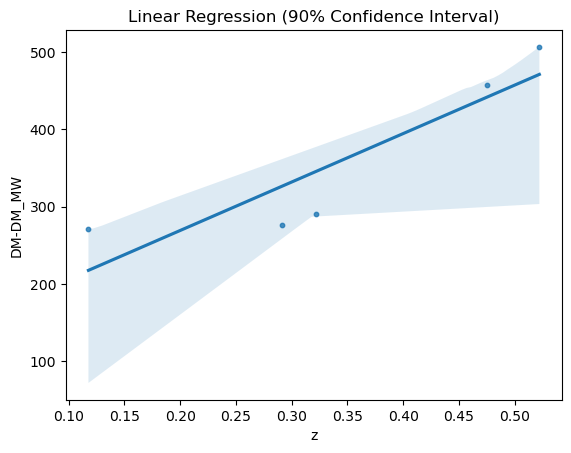

In [34]:
sns.regplot(data=df_mac, x="z",y="DM_ext",ci=90,scatter_kws={"s":10})
plt.ylabel('DM-DM_MW')
plt.title('Linear Regression (90% Confidence Interval)')

In [35]:
df_mac.to_csv("../../Data/FRB_Macquart.csv",index=None)

# Show All FRB $DM_{host}$

In [28]:
df.head()

,FRB,z,DM_ext
0,FRB 20180814A,0.06800,53.30
1,FRB 20181030A,0.00385,12.30
2,FRB 20220529A,0.18390,156.00
3,FRB 20220610A,1.01600,1377.15
4,FRB 20220717A,0.36295,469.04


In [29]:
print(np.max(df['z']))

1.354


In [30]:
dm_vec=np.vectorize(dispersion_measure)
df['DM_host']=(df['DM_ext']-dm_vec(df['z'],H0=HUBBLE,Om=OMEGA_MATTER))*(1.0+df['z'])
df.head()

,FRB,z,DM_ext,DM_host
0,FRB 20180814A,0.06800,53.30,-3.865112
1,FRB 20181030A,0.00385,12.30,9.174762
2,FRB 20220529A,0.18390,156.00,-3.121139
3,FRB 20220610A,1.01600,1377.15,841.701785
4,FRB 20220717A,0.36295,469.04,197.171030


/home/zhuge/miniconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0, 0.5, '#')

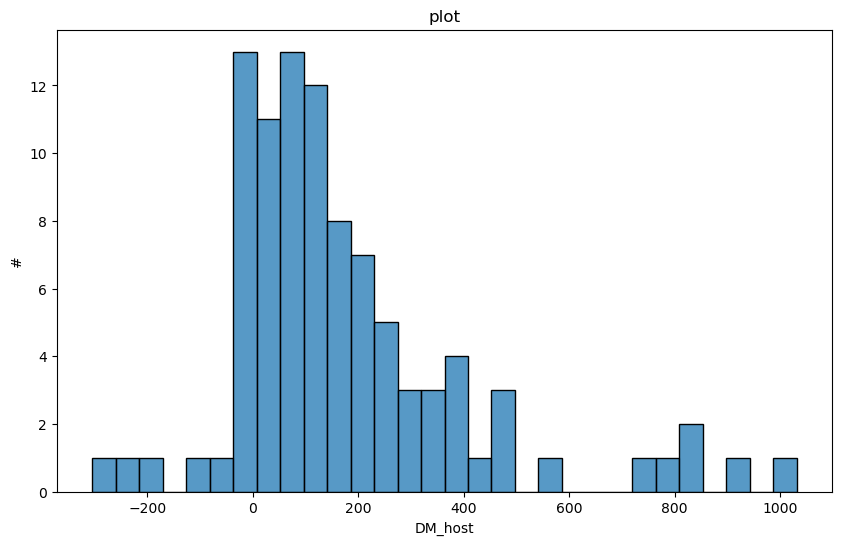

In [31]:
plt.figure(figsize=(10, 6))
# plt.subplot(2, 1, 1)
sns.histplot(data=df['DM_host'], bins=30, stat='count')
plt.title('plot')
plt.xlabel('DM_host')
plt.ylabel('#')